# Trojan Attack com Random Label Flips em VQR

Notebook para avaliar envenenamento em regressao quantica via troca aleatoria de rotulos (targets) no treino.

In [1]:
%pip install -q qiskit qiskit-machine-learning qiskit-algorithms scikit-learn matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

from qiskit import QuantumCircuit
from qiskit.circuit import Parameter
from qiskit.primitives import StatevectorEstimator
from qiskit_machine_learning.optimizers import COBYLA
from qiskit_machine_learning.algorithms.regressors import VQR

np.random.seed(42)

## 1) Dataset de regressao

In [3]:
n_samples = 220
x_min, x_max = -np.pi, np.pi
noise = 0.06

X = np.random.uniform(x_min, x_max, size=(n_samples, 1))
y = np.sin(X[:, 0]) + noise * np.random.randn(n_samples)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

print(f'X_train: {X_train.shape} | X_test: {X_test.shape}')

X_train: (165, 1) | X_test: (55, 1)


## 2) Ataque Random Label Flips para regressao

Seleciona parte do treino e substitui os targets por valores aleatorios no intervalo observado.

In [4]:
def add_random_target_flips(X, y, poison_rate=0.12, random_state=42):
    X_poisoned = X.copy()
    y_poisoned = y.copy()

    rng = np.random.default_rng(random_state)
    n_poison = max(1, int(len(X) * poison_rate))
    poisoned_idx = rng.choice(len(X), size=n_poison, replace=False)

    y_min, y_max = y.min(), y.max()
    y_poisoned[poisoned_idx] = rng.uniform(y_min, y_max, size=n_poison)

    return X_poisoned, y_poisoned, poisoned_idx

## 3) Construindo o VQR

In [5]:
def build_vqr(maxiter=150):
    x_param = Parameter('x')
    theta = Parameter('theta')

    feature_map = QuantumCircuit(1, name='feature_map')
    feature_map.ry(x_param, 0)

    ansatz = QuantumCircuit(1, name='ansatz')
    ansatz.ry(theta, 0)

    estimator = StatevectorEstimator()
    optimizer = COBYLA(maxiter=maxiter)

    return VQR(
        feature_map=feature_map,
        ansatz=ansatz,
        optimizer=optimizer,
        estimator=estimator
    )

## 4) Treino: modelo limpo vs contaminado

In [6]:
POISON_RATE = 0.12
TARGET_VALUE = 0.85

# modelo limpo
vqr_clean = build_vqr()
vqr_clean.fit(X_train, y_train)

# modelo contaminado com random target flips
X_train_poisoned, y_train_poisoned, poisoned_idx = add_random_target_flips(
    X_train, y_train, poison_rate=POISON_RATE, random_state=42
)

vqr_poisoned = build_vqr()
vqr_poisoned.fit(X_train_poisoned, y_train_poisoned)

print(f'Amostras envenenadas no treino: {len(poisoned_idx)} / {len(X_train)}')

No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.
No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


Amostras envenenadas no treino: 19 / 165


## 5) Avaliacao do ataque

In [7]:
pred_clean_model = vqr_clean.predict(X_test)
pred_poisoned_model = vqr_poisoned.predict(X_test)

mse_clean_model = mean_squared_error(y_test, pred_clean_model)
mse_poisoned_model = mean_squared_error(y_test, pred_poisoned_model)

# ASR proxy: taxa de predicoes proximas ao alvo do atacante
tol = 0.12
asr_clean = np.mean(np.abs(pred_clean_model - TARGET_VALUE) <= tol)
asr_poisoned = np.mean(np.abs(pred_poisoned_model - TARGET_VALUE) <= tol)

print('MSE em teste limpo (modelo limpo):', round(mse_clean_model, 4))
print('MSE em teste limpo (modelo contaminado):', round(mse_poisoned_model, 4))
print('ASR proxy em torno do alvo (modelo limpo):', round(asr_clean, 4))
print('ASR proxy em torno do alvo (modelo contaminado):', round(asr_poisoned, 4))

MSE em teste limpo (modelo limpo): 0.0036
MSE em teste limpo (modelo contaminado): 0.0048
ASR proxy em torno do alvo (modelo limpo): 0.2364
ASR proxy em torno do alvo (modelo contaminado): 0.2727


## 6) Visualizacoes

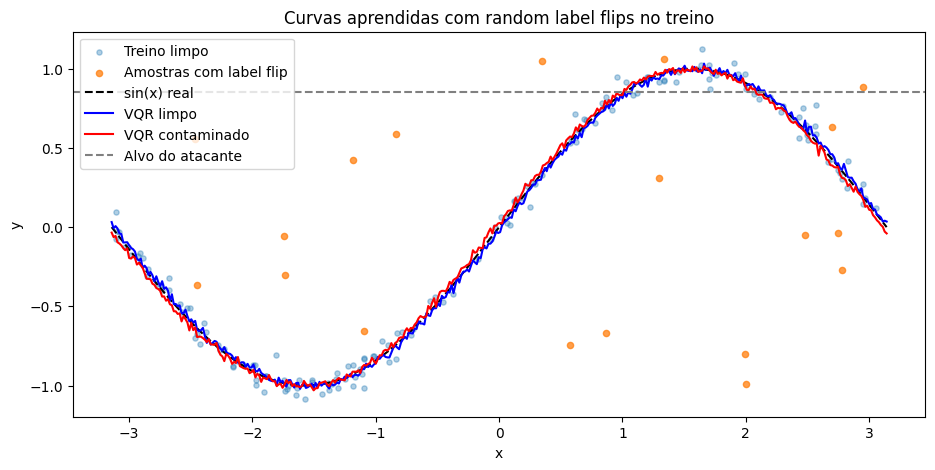

In [8]:
X_plot = np.linspace(x_min, x_max, 400).reshape(-1, 1)
y_plot_clean = vqr_clean.predict(X_plot)
y_plot_poisoned = vqr_poisoned.predict(X_plot)

plt.figure(figsize=(11, 5))
plt.scatter(X_train[:, 0], y_train, s=14, alpha=0.35, label='Treino limpo')
plt.scatter(X_train_poisoned[poisoned_idx, 0], y_train_poisoned[poisoned_idx], s=20, alpha=0.75, label='Amostras com label flip')
plt.plot(X_plot[:, 0], np.sin(X_plot[:, 0]), 'k--', label='sin(x) real')
plt.plot(X_plot[:, 0], y_plot_clean, 'b', label='VQR limpo')
plt.plot(X_plot[:, 0], y_plot_poisoned, 'r', label='VQR contaminado')
plt.axhline(TARGET_VALUE, color='gray', linestyle='--', label='Alvo do atacante')
plt.title('Curvas aprendidas com random label flips no treino')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

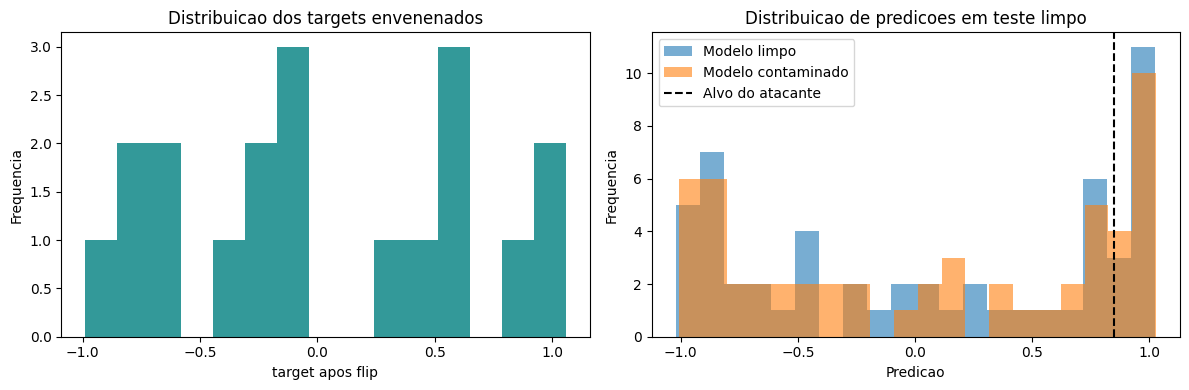

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(y_train_poisoned[poisoned_idx], bins=15, alpha=0.8, color='teal')
ax[0].set_title('Distribuicao dos targets envenenados')
ax[0].set_xlabel('target apos flip')
ax[0].set_ylabel('Frequencia')

ax[1].hist(pred_clean_model, bins=20, alpha=0.6, label='Modelo limpo')
ax[1].hist(pred_poisoned_model, bins=20, alpha=0.6, label='Modelo contaminado')
ax[1].axvline(TARGET_VALUE, color='k', linestyle='--', label='Alvo do atacante')
ax[1].set_title('Distribuicao de predicoes em teste limpo')
ax[1].set_xlabel('Predicao')
ax[1].set_ylabel('Frequencia')
ax[1].legend()

plt.tight_layout()
plt.show()